# **Tutorial 2: The cortical rate-scale representation with aud2cor**


The auditory system does not extract information exclusively from the frequency analysis performed in the cochlea. Instead, in higher-level areas, a spectrotemporal analysis is thought to take place. 

`wav2aud` which builds the auditory spectrogram for a signal, but `aud2cor` moves one step further by exposing the modulation structure of that representation. This function aims to mimic the spectrotemporal analysis performed in the mammalian primary auditory cortex (A1). The model is based on physiological data rather than a biophysical approach. \[[1](#References)\]


## **Theoretical background**
Broadly, the computations performed by `aud2cor` are as follows: 
- A 2-D FFT is taken because the auditory spectrogram is a 2-D signal: one axis is time and the other is frequency. The FFT makes it possible to see how energy is distributed across temporal and spectral modulation patterns.

- Padding is used so that the FFT can be computed on a power-of-two size, which makes the implementation faster and more stable. It also helps avoid wrap-around artifacts when the transform is later inverted.

- Only half of the spatial spectrum is stored initially because the input is real-valued and its Fourier transform is symmetric. Keeping only one half is enough for the later steps and reduces memory use.

- Temporal modulation filtering applies a set of filters along the time axis to separate slow from fast changes. These filters are parameterized by rate, which describes how quickly a modulation repeats over time.

- Positive and negative rates correspond to modulations with opposite phase directions. In practice, the implementation keeps both so that the transformation can represent motion in either direction.

- The first inverse FFT returns the result to the time domain after temporal filtering. This step converts the filtered modulation representation back into a form that can be combined with spectral processing.

- Spectral modulation filtering is then applied along the frequency axis. This separates broad and narrow modulation patterns across frequency channels.

- A second inverse FFT brings the result back into the original frequency domain. At that point, the representation has been transformed into a cortical rate-scale map.

- The implementation suggests that the filters are separable. Separable filtering would make the computation efficient because the temporal and spectral operations can be applied one axis at a time rather than requiring a 2D filter bank.

- The processing order is time-first and then frequency-second because the algorithm first extracts temporal modulation structure and then uses that result to extract spectral modulation structure. This mirrors the idea that rate and scale are two different layers of analysis.


## **Using aud2cor**

For this tutorial, we will load an audio file from one of the examples and create an audiogram, as in Tutorial 1. We will then pass that result to `aud2cor`.

Parameters specific to `aud2cor` are:

- `tp_margin`: controls how much temporal margin is added around the representation.
- `sp_margin`: controls how much spectral margin is added around the representation.
- `bandpass`: changes the passband of the filters.
- `tpfilt_cf`: defines the center frequencies of the temporal modulation filters.
- `spfilt_ripples`: defines the center frequencies of the spectral modulation filters.
- `fname`: if given, writes the complex output to a binary file.

The parameters for `wav2aud` can still be passed in, and these will be used to write the header of the binary file.

For most exploratory work, the defaults are a good place to start.


### **Step 1: Generate audiogram**
Using the same steps as in Tutorial 1, we can choose an example sound using the dropdown menu and generate the audiogram using `wav2aud`. 

In [ ]:
from neural_audio.examples.sounds.load import load_sound_file_paths2
import soundfile as soundf
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, Audio

# Get list of sound files. To get synthetic sounds, set synthetic=True, otherwise natural sounds will be used.
sound_files = load_sound_file_paths2(synthetic=False)
sound_file_names = [Path(file).name for file in sound_files]

# Create dropwdown widget to select and play sound file
dropdown = widgets.Dropdown(options=sound_file_names, description='Sound file:')
audio_player = widgets.Output()
sound_file_path = sound_files[1]

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        global sound_file_path
        for file in sound_files:
            if Path(file).name == change['new']: sound_file_path = file
        audio_player.clear_output()
        with audio_player:
            display(Audio(str(sound_file_path), autoplay=False))

dropdown.observe(on_change)
dropdown.value = sound_file_names[1]  # Set default value to the first sound file
display(dropdown, audio_player)

Dropdown(description='Sound file:', index=1, options=('ripple_stim_1.wav', 'spectral_modulations_1.wav', 'temp…

Output()

Audiogram shape == [128 frequencies, 500 time points]


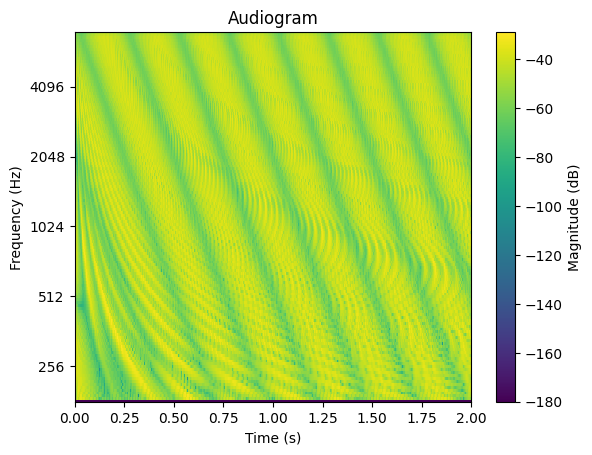

In [3]:
from neural_audio.wav2aud import wav2aud
from neural_audio.utils.visualize_outputs import plot_spectrogram

# Compute an audiogram with default parameters
waveform, sampling_rate = soundf.read(sound_file_path)
time_points_audiogram, frequencies_audiogram, audiogram  = wav2aud(waveform)

print(f"Audiogram shape == [{audiogram.shape[0]} frequencies, {audiogram.shape[1]} time points]")

# For convenience, visualize the output
plot_spectrogram(audiogram, time_points_audiogram, frequencies_audiogram, title='Audiogram')


### **Step 2: Generate cortical representation**
To get the correct output dimensions, the **transpose** of the audiogram must be passed as input to `aud2cor`. Since we used default parameters for `wav2aud`, it is safe to also use the defaults for `aud2cor`. Note that **this step is far more computationally intensive and may take a few minutes**.

In [ ]:
from neural_audio.aud2cor import aud2cor
cr = aud2cor(audiogram.T) # NOTE that the transpose is used here
print(f"Cortical representation shape: {cr.shape}")

num_rates, num_rates, n_time, n_freq = cr.shape
print(f"Number of rates: {num_scales}")
print(f"Number of rate channels: {num_rates}")
print(f"Time frames: {n_time}")
print(f"Frequency frames: {n_freq}")

Cortical representation shape: (32, 64, 500, 128)
Number of scales: 32
Number of rate channels: 64
Time frames: 500
Frequency frames: 128


### **Step 3: Visualization**
The output of `aud2cor` has four dimensions: scale, rate, time, and frequency. Because of this, it is useful to create 2D projections along specific axes. We can use the function `plot_cr_projection` from utils to do so. It requires the following arguments:
- `cr` - The cortical representation (output of aud2cor), an array [scale x rate x time x frequency]
- `rates` - The rate vector used to construct the cortical representation
- `scales` - The scale vector used to construct the cortical representation
- `frequencies`- The audiogram frequencies


In [ ]:
import numpy as np
from neural_audio.utils.visualize_outputs import plot_cr_projection

rates = 2 ** np.linspace(np.log2(0.5), np.log2(128), 32)
scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 32)
plot_cr_projection(cr, rates, scales=scales, frequencies=frequencies_audiogram)

## **Alternative configurations**
This section will cover the role of the following key parameters and how to adjust them beyond the defaults:
- `sp/tp_margin`
- `bandpass`
- `rates` and `scales`

---
### **Temporal and spectral margins**
The output array of `aud2cor` has dimensions `(num_scales, num_rates * 2, N + 2 * dN, M + 2 * dM)`. `num_rates` gets multiplied by two to account for both upwards and downwards directions. `dM` and `dN` are the margins applied symmetrically to the time and frequency axis, controlled by the parameters `sp_margin` and `tp_margin`.

##### **Theoretical background**
In the main loop of aud2cor, a 2D wavelet transform is performed, where the signal is convolved with a wavelet, first along the temporal and then along the log-frequency axis. It is the filter-generating functions that supply this wavelet (more detail on this in later sections).

When doing a wavelet transform, you convolve your signal with a wavelet, which essentially evaluates "at this position, how similar is my signal to this wavelet?". The problem is, a wavelet is not a single point, so it can 'hang off' the edges of your signal, which is why it is useful to solve this with zero-padding.

The result of convolving a wavelet with these made-up zeroes is in practice pretty useless, unless you want to reconstruct your original signal at some point in the future. This is why `sp_margin` and `tp_margin` exist; so that you can choose to keep these values (and how many to keep) to use during reconstruction.

##### **Usage**
`sp_margin` and `tp_margin` control what we call the temporal and spectral margins and must be a real number between 0 and 1. These values calculate the margin index used to extract the relevant values from the wavelet transform. The margin is applied symmetrically to either side of the main spectral content.

The margin index (`dM` or `dN`) is calculated according to

$$dM = \left \lceil{\frac{M}{2} \times \textrm{sp margin}}\right \rceil $$


(likewise for `N, tp_margin`). Maximum ‘fullness’ of the margin will be roughly half the axis length. So if you have say, 20 time points, if you set `tp_margin = 1`, the index dM will be 10. If you have 21 time points, it will also be 10 due to the `ceil` operation.

### **Rates and scales**
- The **rate** vector describes the temporal modulation rates used to construct the temporal filters (how fast a signal changes in time)
- The **scale** vector describes the spectral modulation rates used to construct the spectral filters (how fast the signal changes across frequency)

The plots below illustrate different synthetic signals constructed with simple spectral or temporal modulations, or both (a ripple).

In [19]:
# setup
from neural_audio.utils.mathfuncs import gen_spectral_modulations_scale, gen_temporal_modulations_rate, gen_ripple
from neural_audio.wav2aud import wav2aud
from neural_audio.utils.visualize_outputs import plot_spectrogram
import numpy as np
import matplotlib.pyplot as plt

scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 32) # default scales
rates = 2 ** np.linspace(np.log2(0.5), np.log2(64), 32) # default rates

#### Effect of rate on a temporally-modulated signal
This is an example of a signal that contains no spectral changes - all frequencies are present, but only in short bursts, meaning only temporal modulations are present.

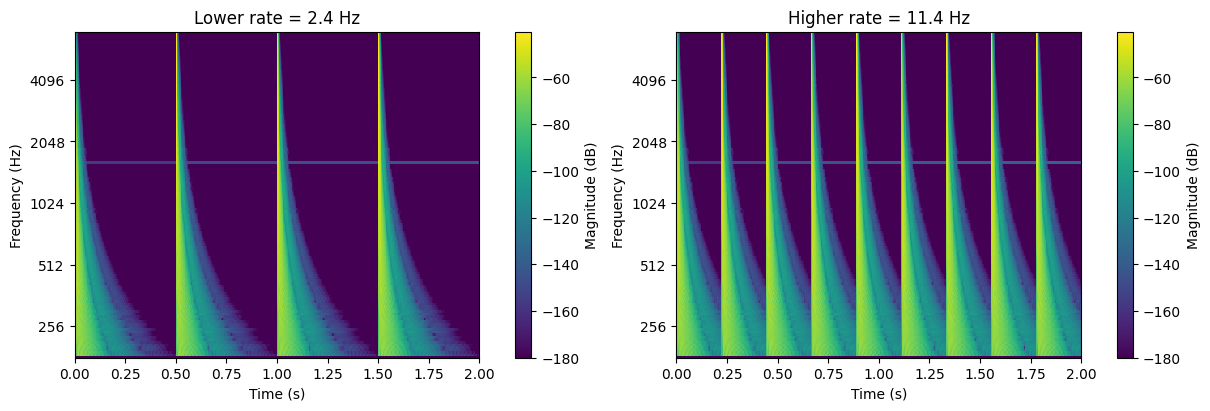

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

plt.sca(axes[0])
waveform = gen_temporal_modulations_rate(rates[10])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Lower rate = {rates[10]:.1f} Hz")

plt.sca(axes[1])
waveform = gen_temporal_modulations_rate(rates[15])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Higher rate = {rates[20]:.1f} Hz")

plt.show()

#### Effect of scale on a spectrally-modulated signal
Analogously to the above example, the signal below contains only spectral modulations. It is constant in time, but made up of various frequencies.

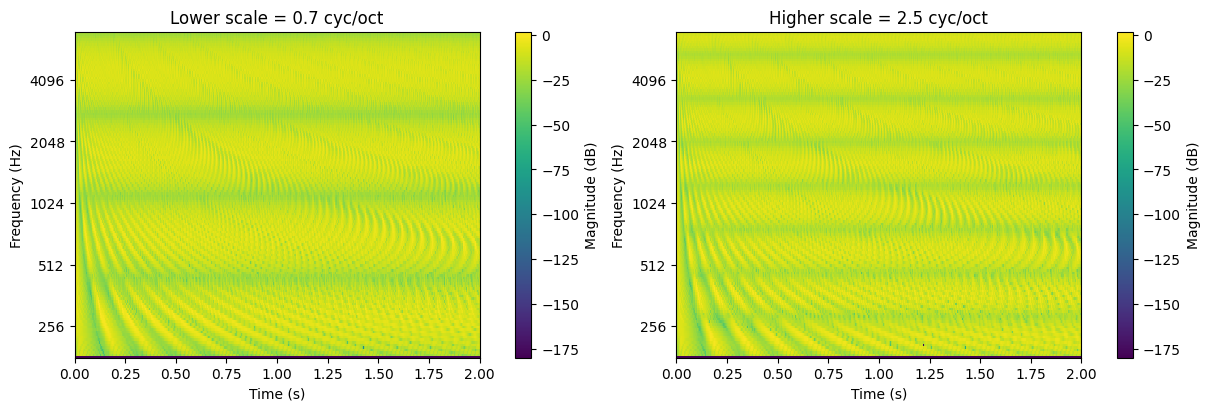

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

plt.sca(axes[0])
waveform = gen_spectral_modulations_scale(scales[5])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Lower scale = {scales[10]:.1f} cyc/oct")

plt.sca(axes[1])
waveform = gen_spectral_modulations_scale(scales[10])
tp, freqs, aud = wav2aud(waveform)
plot_spectrogram(aud, tp, freqs, title=f"Higher scale = {scales[20]:.1f} cyc/oct")

plt.show()

#### Effect of rate and scale on a ripple
Ripples are defined as "broadband noise with sinusoidally modulated spectrotemporal envelopes with different parameters"\[[1](#References)\]. In other words, this means the signal contains energy across a wide range of frequencies, but that energy is arranged in a sinusoidal pattern that varies across both time and frequency.

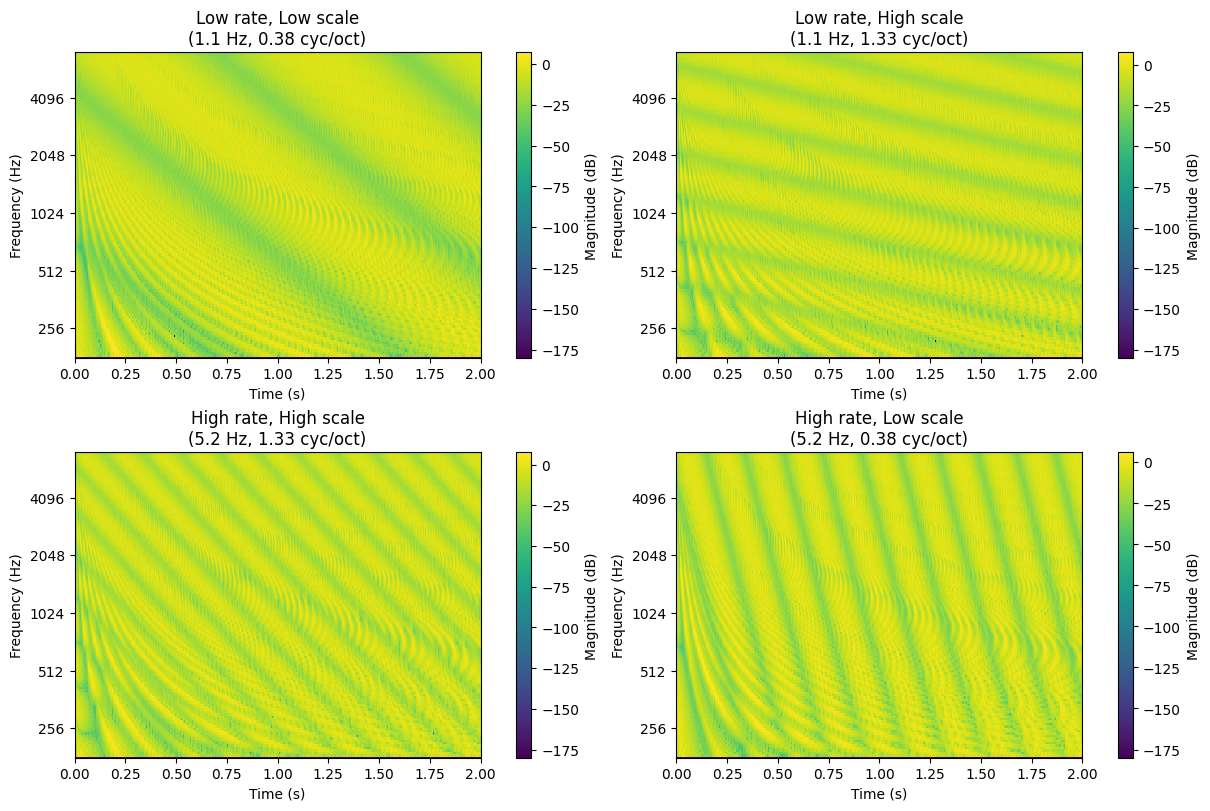

In [21]:
# Low/high values to illustrate the effect
low_rate  = rates[5]
high_rate = rates[15]

low_scale  = scales[5]
high_scale = scales[15]

configs = [
    (low_rate,  low_scale,  "Low rate, Low scale"),
    (low_rate,  high_scale, "Low rate, High scale"),
    (high_rate, high_scale, "High rate, High scale"),
    (high_rate, low_scale,  "High rate, Low scale"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for ax, (rate, scale, title) in zip(axes.flat, configs):

    waveform = gen_ripple(rate=rate, scale=scale)

    t, freqs, aud = wav2aud(waveform)

    plt.sca(ax)
    plot_spectrogram(
        aud,
        t,
        freqs,
        title=f"{title}\n({rate:.1f} Hz, {scale:.2f} cyc/oct)"
    )

plt.show()

---
### **Bandpass indicator**
The `bandpass` parameter controls the passbands of filters produced by `gen_corf` and `gen_corf`. It is a **boolean** value.
- if `bandpass = 1`, only bandpass filters will be generated
- if `bandpass = 0`, lowpass filters will be generated for the first rate and scale, and highpass filters will be generated for the last rate and scale. All the intermediate rate and scale values will generate bandpass filters.
This is a global property, meaning that it will affect *both* of the filter-generating functions at once.

The effects of this can be seen in the section below describing the filter-generating functions in more detail.

## **About the filters**

The two filter generators are `gen_cort` and `gen_corf`, which return transfer functions (frequency-domain representation) for a temporal or spectral filter, respectively, based on an input set of parameters. The transfer function describes how the filter would treat each frequency component of a signal it is applied to. In other words, the transfer function specifies the gain (and, in general, phase shift) applied to each modulation frequency. 

First, a 2D FFT is performed on the audiogram, representing it in terms of temporal modulation frequencies (rates) and spectral modulation frequencies (scales). We call this output `Y`. The 'wavelet transform' in `aud2cor` is implemented as two separable convolutions involving `Y`: one with a temporal modulation filter and one with a spectral modulation filter. Together these are equivalent to convolution with a separable 2D spectrotemporal wavelet.  By the convolution theorem, convolution along the time or log-frequency axis is equivalent to multiplication in the corresponding temporal or spectral modulation frequency domain. This explains why the filters operate in the frequency domain; using a multiplication is more computationally efficient than a convolution operation, though the end result is identical. 

### Temporal modulation filters
`gen_cort` generates filters that are selective to specific temporal modulations, which we call 'rates', measured in Hertz. It produces analytic filters, which means they have zero gain (no response) at negative frequencies. However, each filter can be paired with its complex-conjugate counterpart to capture both directions of temporal modulation. It is causal, meaning its output at any time depends only on current and past inputs, not future inputs.

### Spectral modulation filters
`gen_corf` generates filters that are selective to specific spectral modulations, which we call 'scales', measured in cycles per octave. The function outputs a real-valued transfer function in the spectral modulation domain, so they selectively amplify or attenuate spectral modulation patterns and contain no phase-related changes or information.

---
Below, we illustrate some important features of the filter bank.

In [16]:
# Global parameter setup and imports
from neural_audio.aud2cor import gen_cort, gen_corf
from neural_audio.utils.visualize_outputs import plot_tempfilt_response, plot_spectfilt_response
import matplotlib.pyplot as plt
import numpy as np

N, M = audiogram.T.shape # shape (timepoints, freq_channels)
# FFT Padding
N_pad = int(2 ** np.ceil(np.log2(N)))
M_pad = int(2 ** np.ceil(np.log2(M)))

scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 32) # default scales
rates = 2 ** np.linspace(np.log2(0.5), np.log2(64), 32) # default rates
fps = 1000 / 4 # frames per second, calculated with default num_frames
ch_per_oct = 20 if M == 95 else 24
num_rates, num_scales = len(rates), len(scales)

### **Plotting the frequency response**
Here we can see the shape of the different filters for some example rates and scales. A few important notes:
- If `bp = 0` it is *always* the first index of the rate/scale that produces the lowpass filter and the last index that
    produces the highpass filter.
- The plots for temporal filters have different resolutions depending on what rate they are tuned to. This is an artifact
    from the choice of FFT bin relative to the bandwidth (which is proportional to the rate). It does not affect filter behavior.

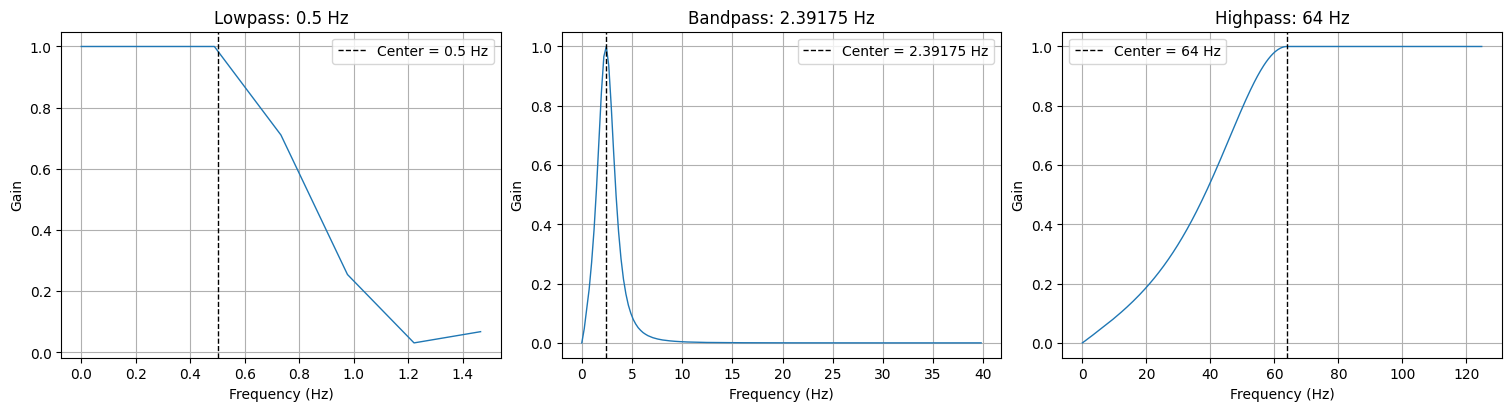

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
indexes_to_plot = [0, 10, num_rates-1]

for ax, rdx in zip(axes, indexes_to_plot):
    bp = 0
    H = gen_cort(rates[rdx], N_pad, fps, [rdx + 1 + bp, num_rates + bp * 2])
        
    _title = f"Bandpass: {rates[rdx]:g} Hz"
    _max_freq = 40
    if bp == 0:
        if rdx == 0:
            _title = f"Lowpass: {rates[rdx]:g} Hz"
            _max_freq = 1.5
        elif rdx == num_rates-1:
            _title = f"Highpass: {rates[rdx]:g} Hz"
            _max_freq = None
            

    plot_tempfilt_response(H, fps, center=rates[rdx], max_freq=_max_freq, title=_title, ax=ax)
 
plt.show()

Here we can see the frequency responses of the spectral filters. Note that we set `bp = 0` so that all filter shapes can be seen, but the default is `bp = 1` (all bandpass)

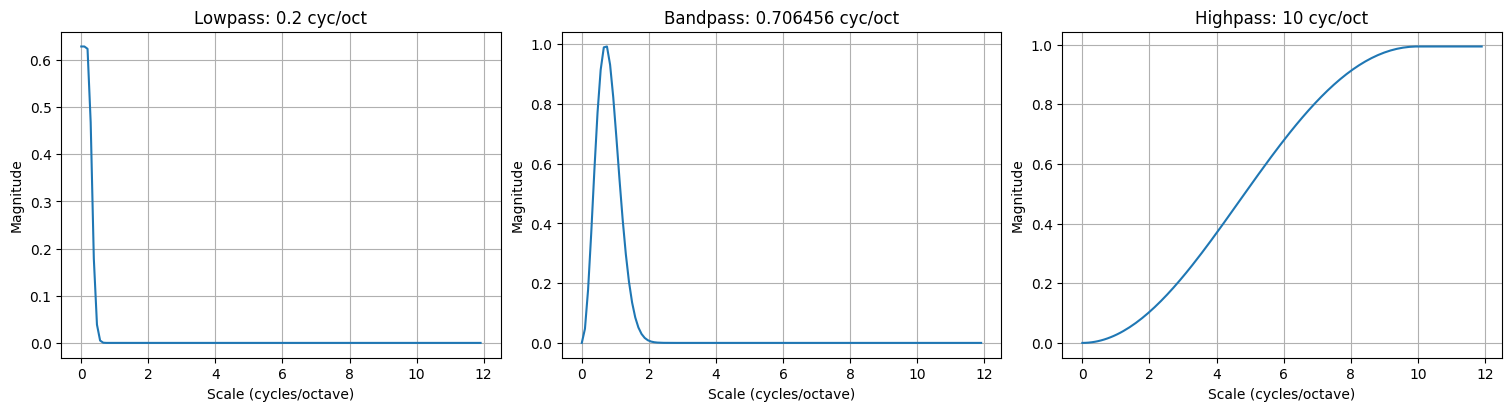

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
scales_to_plot = [scales[0], scales[10], scales[-1]]  # or whichever scales you want

for ax, scale in zip(axes, scales_to_plot):
    sdx = np.argmin(np.abs(scales - scale))
    bp = 0
    H = gen_corf(scales[sdx], M_pad, ch_per_oct,
                 [sdx + 1 + bp, num_scales + bp * 2])
    
    _title = f"Bandpass: {scales[sdx]:g} cyc/oct"
    if bp == 0:
        if sdx == 0:
            _title = f"Lowpass: {scales[sdx]:g} cyc/oct"
        elif sdx == num_scales-1:
            _title = f"Highpass: {scales[sdx]:g} cyc/oct"

    plot_spectfilt_response(
        H,
        ch_per_oct,
        title=_title,
        ax=ax
    )

plt.show()

### **Using an alternative function for `gen_corf`**

Two functions can be used to derive the spectral transfer function:
- A Gabor function
    $$ e^{-C (x-1)^2} + e^{-C (x+1)^2} $$
    
- A Gaussian function
    $$x^2 e^{(1-x^2)}$$

where $C$ is a constant and $x$ denotes the octave offset (channels per 0.5 cycles)

This can be specified through the `kind` parameter. Below an example is given for a bandpass filter using each, for the same scale, to illustrate the difference in the resulting filter's shape.

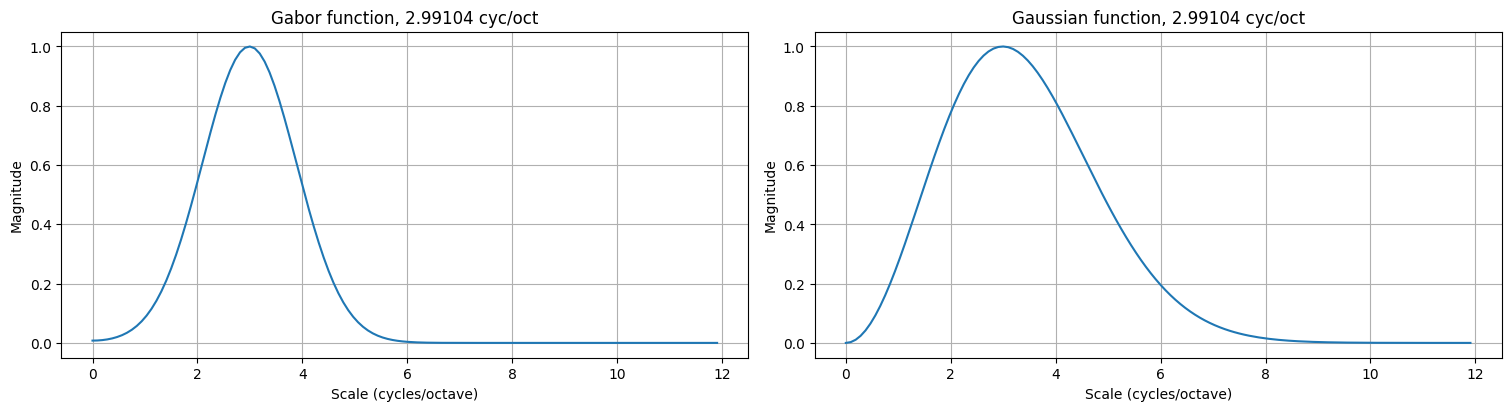

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)
func_options = [1,2]
for ax, func in zip(axes, func_options):
    sdx = 10 # arbitrarily chosen index
    H = gen_corf(scales[sdx], M_pad, ch_per_oct, func)
    
    if func == 1:
        _title = f"Gabor function, {scales[sdx]:g} cyc/oct"
    else:
        _title = f"Gaussian function, {scales[sdx]:g} cyc/oct"


    plot_spectfilt_response(
        H,
        ch_per_oct,
        title=_title,
        ax=ax
    )

plt.show()

# References
[1] Chi, Taishih & Ru, Powen & Shamma, Shihab (2005),
        "Multiresolution spectrotemporal analysis of complex sounds" ,
        The Journal of the Acoustical Society of America, 118, 887-906, 
        10.1121/1.1945807